Imports and Device

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# get device
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# allot values
BATCH_SIZE = 64
TEST_BATCH_SIZE = 10
LEARNING_RATE = 0.001
EPOCHS = 20
LATENT_DIM = 32
SEED = 42

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
print('Device:', DEVICE)

Device: cuda


Transform, Data and Loaders

In [ ]:
def get_dataloaders(batch_size, test_batch_size):
    # transforms
    transform = transforms.Compose([
        transforms.ToTensor()
    ])

    # data
    train_data = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
    test_data = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

    # loaders
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=test_batch_size, shuffle=False)

    return train_loader, test_loader

Encoder and Decoder

In [ ]:
class MLPAuto(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__() # inialize

        # encoder func
        self.encoder = nn.Sequential(
            # 28*28 into 784
            nn.Flatten(),
            nn.Linear(784, 256),
            # negative nos to zero
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            # no ReLU here
            nn.Linear(128, latent_dim)
        )

        # decoder func
        self.decoder = nn.Sequential(
            # 32 to 128
            nn.Linear(latent_dim, 128),
            # negative nos to zero
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            # convert to 0-1
            nn.Sigmoid()
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        x = self.decoder(z)
        return x.view(-1, 1, 28, 28)

    # forward func
    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)

Training model


In [ ]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    #train
    model.train()
    run_train_loss = 0.0
    total_samples = 0

    for imgs, _ in dataloader:
        imgs = imgs.to(device)
        # clear gradients
        optimizer.zero_grad()
        outputs = model(imgs)
        # grading loss
        loss = criterion(outputs, imgs)
        # back propagation
        loss.backward()
        optimizer.step()

        # adds up the bad score
        run_train_loss += loss.item() * imgs.size(0)
        total_samples += imgs.size(0)

    # average
    return run_train_loss / total_samples

Evaluating model

In [ ]:
def evaluate_model(model, dataloader, criterion, device):
    # turn off gradients
    model.eval()
    run_test_loss = 0.0
    total_samples = 0

    # stop learning
    with torch.no_grad():
        for test_imgs, _ in dataloader:
            test_imgs = test_imgs.to(device)
            test_outputs = model(test_imgs)
            # grade loss
            loss1 = criterion(test_outputs, test_imgs)

            run_test_loss += loss1.item() * test_imgs.size(0)
            total_samples += test_imgs.size(0)

    # average
    return run_test_loss / total_samples

Plotting

In [ ]:
def plot_loss_curve(train_loss, test_loss, epochs):
    # plot
    plt.figure(figsize=(8,4))
    plt.plot(range(1, epochs + 1), train_loss, color='red', marker='o', label='Train Loss')
    plt.plot(range(1, epochs + 1), test_loss, color='yellow', linestyle='--', marker='s', label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('Autoencoder Reconstruction Loss')
    plt.legend()
    # grids
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.savefig('autoencoder_loss_curve.png', dpi=150)
    # display
    plt.show()

Error Analysis

In [ ]:
def plot_reconstructions(model, dataloader, device):
    # test mode
    model.eval()

    data_iterator = iter(dataloader)
    sample_imgs, _ = next(data_iterator)
    sample_imgs = sample_imgs.to(device)

    # formed ones
    with torch.no_grad():
        reconstructed_imgs = model(sample_imgs)

    # move from gpu to cpu
    sample_imgs = sample_imgs.cpu().numpy()
    reconstructed_imgs = reconstructed_imgs.cpu().numpy()

    fig, axes = plt.subplots(nrows=2, ncols=10, figsize=(15, 4))

    for i in range(10):
        # correct ones in top row
        axes[0, i].imshow(np.squeeze(sample_imgs[i]), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Original', loc='left', fontweight='bold')

        # wrong ones in bottom row
        axes[1, i].imshow(np.squeeze(reconstructed_imgs[i]), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Formed', loc='left', fontweight='bold')

    plt.tight_layout()
    plt.savefig('autoencoder_visual_results.png', dpi=150)
    plt.show()

Latent dim experiment

In [ ]:
def run_latent_experiment(latent_dims, train_loader, eval_loader, device, epochs=10):
    results = {}
    for ldim in latent_dims:
        exp_model = MLPAuto(latent_dim=ldim).to(device)
        exp_criterion = nn.MSELoss()
        exp_optimizer = optim.Adam(exp_model.parameters(), lr=LEARNING_RATE)
        for _ in range(epochs):
            train_epoch(exp_model, train_loader, exp_criterion, exp_optimizer, device)
        loss = evaluate_model(exp_model, eval_loader, exp_criterion, device)
        results[ldim] = loss
        print(f"Latent dim {ldim:4d} → Test MSE: {loss:.5f}")
    plt.figure(figsize=(7, 4))
    plt.plot(list(results.keys()), list(results.values()), marker='o', color='steelblue')
    plt.xlabel('Latent Dimension')
    plt.ylabel('Test MSE')
    plt.title('Bottleneck Size vs Reconstruction Loss')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.savefig('latent_dim_experiment.png', dpi=150)
    plt.show()
    return results

Results

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.9MB/s]


Epoch [01/20] | Train MSE: 0.03044 | Test MSE: 0.02003
Epoch [02/20] | Train MSE: 0.01826 | Test MSE: 0.01685
Epoch [03/20] | Train MSE: 0.01585 | Test MSE: 0.01506
Epoch [04/20] | Train MSE: 0.01429 | Test MSE: 0.01387
Epoch [05/20] | Train MSE: 0.01322 | Test MSE: 0.01301
Epoch [06/20] | Train MSE: 0.01243 | Test MSE: 0.01252
Epoch [07/20] | Train MSE: 0.01186 | Test MSE: 0.01179
Epoch [08/20] | Train MSE: 0.01140 | Test MSE: 0.01140
Epoch [09/20] | Train MSE: 0.01100 | Test MSE: 0.01099
Epoch [10/20] | Train MSE: 0.01065 | Test MSE: 0.01077
Epoch [11/20] | Train MSE: 0.01036 | Test MSE: 0.01046
Epoch [12/20] | Train MSE: 0.01010 | Test MSE: 0.01011
Epoch [13/20] | Train MSE: 0.00989 | Test MSE: 0.00997
Epoch [14/20] | Train MSE: 0.00969 | Test MSE: 0.00981
Epoch [15/20] | Train MSE: 0.00953 | Test MSE: 0.00973
Epoch [16/20] | Train MSE: 0.00938 | Test MSE: 0.00953
Epoch [17/20] | Train MSE: 0.00924 | Test MSE: 0.00948
Epoch [18/20] | Train MSE: 0.00913 | Test MSE: 0.00928
Epoch [19/

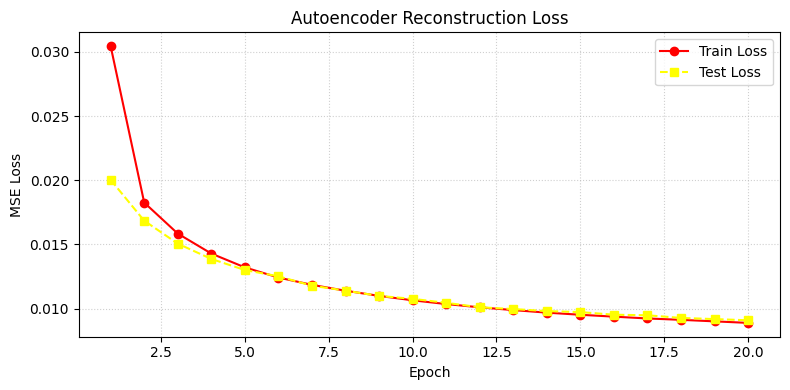

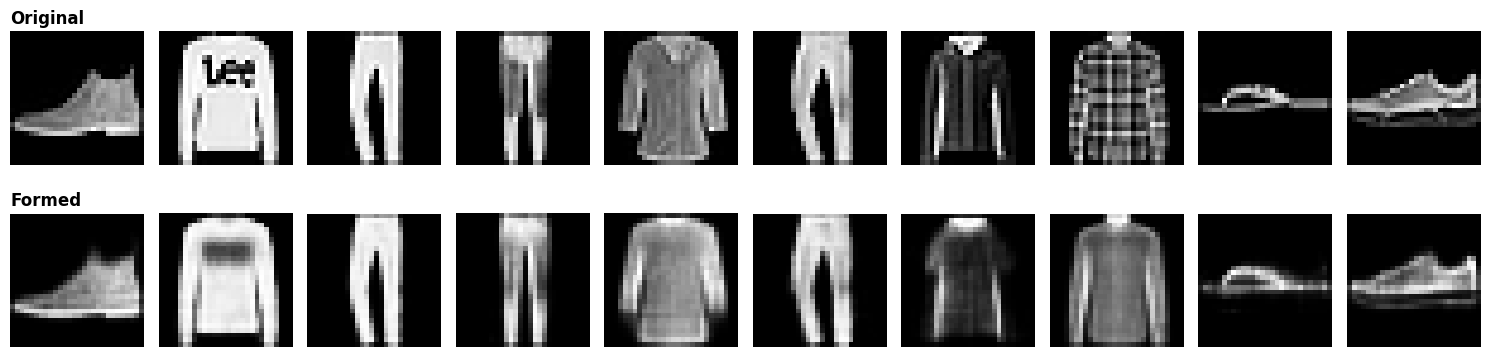


Latent Dim Experiment:
Latent dim    4 → Test MSE: 0.01861
Latent dim    8 → Test MSE: 0.01399
Latent dim   16 → Test MSE: 0.01178
Latent dim   32 → Test MSE: 0.01062
Latent dim   64 → Test MSE: 0.01022
Latent dim  128 → Test MSE: 0.01016


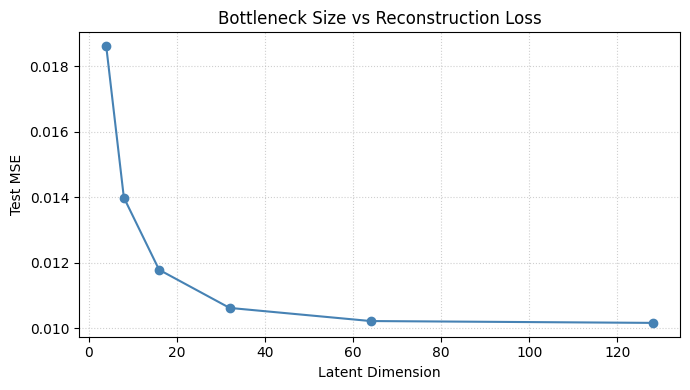

In [ ]:
if __name__ == "__main__":
    train_loader, test_loader = get_dataloaders(BATCH_SIZE, TEST_BATCH_SIZE)

    model = MLPAuto(latent_dim=LATENT_DIM).to(DEVICE)

    # MSE grading
    criterion = nn.MSELoss()
    # optim
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # empty lists
    train_loss = []
    test_loss = []

    # make it infinity
    best_test_loss = float('inf')

    for epoch in range(EPOCHS):
        avg_train_loss = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
        train_loss.append(avg_train_loss)

        avg_test_loss = evaluate_model(model, test_loader, criterion, DEVICE)
        test_loss.append(avg_test_loss)

        print(f"Epoch [{epoch+1:02d}/{EPOCHS:02d}] | Train MSE: {avg_train_loss:.5f} | Test MSE: {avg_test_loss:.5f}")

        # saving code
        if avg_test_loss < best_test_loss:
            best_test_loss = avg_test_loss
            torch.save(model.state_dict(), 'best_autoencoder.pth')

    print(f"\nFinished Learning. Our best test score was: {best_test_loss:.5f}")

    plot_loss_curve(train_loss, test_loss, EPOCHS)

    model.load_state_dict(torch.load('best_autoencoder.pth', weights_only=True))
    plot_reconstructions(model, test_loader, DEVICE)

    print("\nLatent Dim Experiment:")
    run_latent_experiment([4, 8, 16, 32, 64, 128], train_loader, test_loader, DEVICE, epochs=10)